In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
file_path = "Loan.csv" # Путь к вашему файлу
df = pd.read_csv(file_path)

## 1. Обзор датасета и очистка данных
Для начала посмотрим на размер датасета, проверим наличие полных дубликатов и обработаем явные выбросы, которые могут сбить модель с толку (например, аномально высокие доходы, которые встречаются крайне редко).

In [11]:
print(f"Изначальный размер датасета: {df.shape[0]} строк и {df.shape[1]} признаков.")

# 1. Удаление полных дубликатов
duplicates = df.duplicated().sum()
print(f"Количество полных дубликатов: {duplicates}")
df = df.drop_duplicates()

# 2. Обработка выбросов теперь по чистой колонке MonthlyIncome
Q1 = df['MonthlyIncome'].quantile(0.25)
Q3 = df['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = df[(df['MonthlyIncome'] < lower_bound) | (df['MonthlyIncome'] > upper_bound)].shape[0]
print(f"Найдено выбросов по колонке MonthlyIncome: {outliers_count}")

# Оставляем только нормальные значения
df = df[(df['MonthlyIncome'] >= lower_bound) & (df['MonthlyIncome'] <= upper_bound)]
print(f"Размер датасета после очистки: {df.shape[0]} строк.")

print("\nРаспределение целевой переменной:")
display(df['LoanApproved'].value_counts(normalize=True))

Изначальный размер датасета: 20000 строк и 36 признаков.
Количество полных дубликатов: 0
Найдено выбросов по колонке MonthlyIncome: 925
Размер датасета после очистки: 19075 строк.

Распределение целевой переменной:


,proportion
LoanApproved,
0,0.795177
1,0.204823


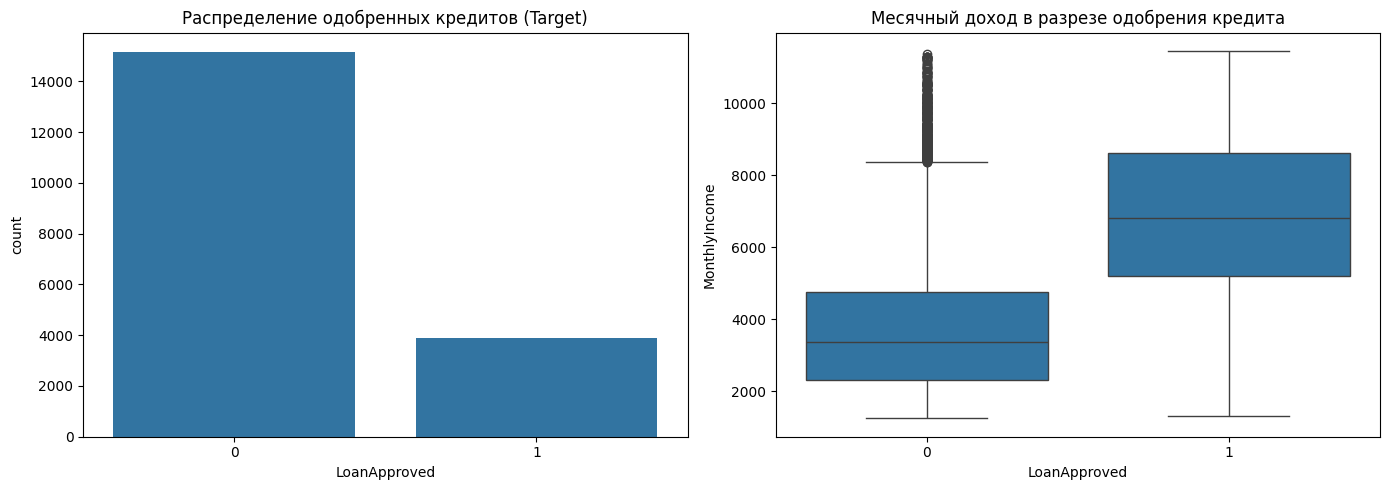

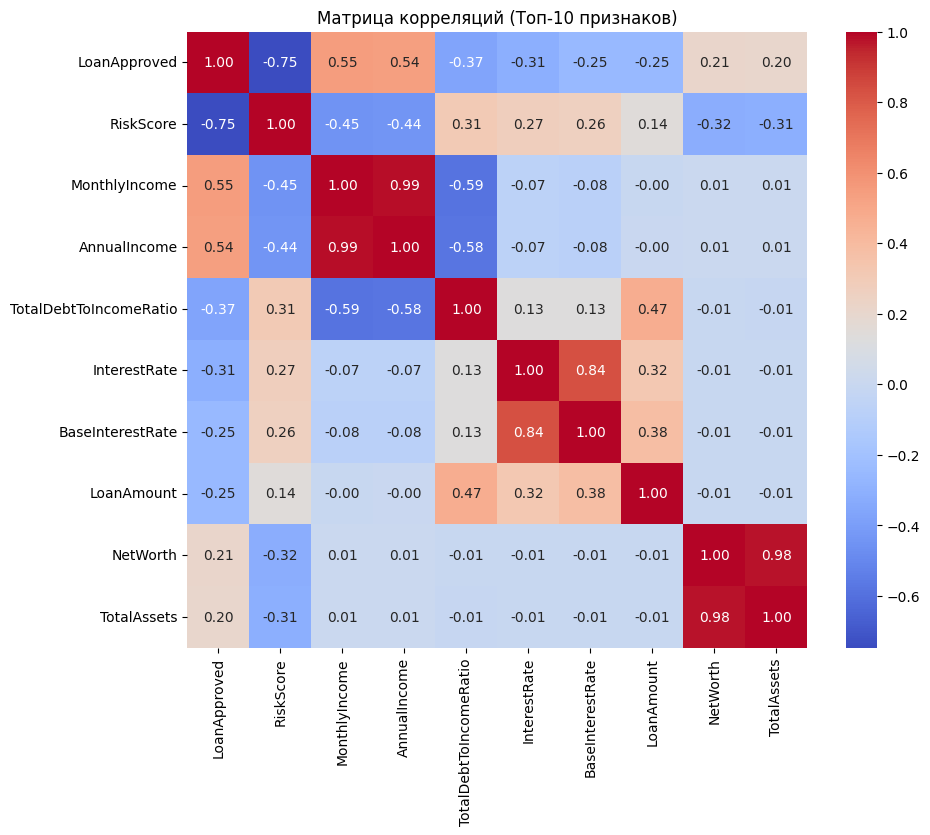

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Распределение целевой переменной
sns.countplot(data=df, x='LoanApproved', ax=axes[0])
axes[0].set_title('Распределение одобренных кредитов (Target)')

# График 2: Меняем на МЕСЯЧНЫЙ доход
sns.boxplot(data=df, x='LoanApproved', y='MonthlyIncome', ax=axes[1])
axes[1].set_title('Месячный доход в разрезе одобрения кредита')

plt.tight_layout()
plt.show()

# Корреляционная матрица для топ-10 числовых признаков по отношению к таргету
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=np.number)
top_corr_features = numeric_df.corr()['LoanApproved'].abs().sort_values(ascending=False).head(10).index
sns.heatmap(numeric_df[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляций (Топ-10 признаков)')
plt.show()

## 3. Feature Engineering и предотвращение Data Leakage

**Важное замечание об утечке данных (Data Leakage):**
В исходном датасете присутствуют колонки `InterestRate` (процентная ставка), `BaseInterestRate` и `MonthlyLoanPayment` (ежемесячный платеж). Эти параметры формируются банком *только после* того, как принято принципиальное решение о выдаче кредита. Если оставить их в обучающей выборке, модель научится "заглядывать в будущее" — она поймет, что если ставка рассчитана, значит кредит одобрен. Это дает нереалистично высокие метрики (ROC-AUC около 0.99), которые на реальных новых данных не подтвердятся.

Поэтому мы **удаляем** эти признаки, а также неинформативные колонки вроде даты заявки и скорингового балла, чтобы построить честную модель (Baseline).

Также мы создадим несколько **новых признаков**, которые отражают финансовую нагрузку и надежность клиента более комплексно.

In [13]:
df_clean = df.copy()

# 1. Feature Engineering (Создание новых признаков на базе MonthlyIncome)
# Доход на одного члена семьи в месяц
df_clean['IncomePerDependent'] = df_clean['MonthlyIncome'] / (df_clean['NumberOfDependents'] + 1)

# Отношение длины кредитной истории к возрасту
df_clean['CreditHistoryToAge'] = df_clean['LengthOfCreditHistory'] / df_clean['Age']

# Отношение активов к обязательствам
df_clean['AssetsToLiabilities'] = df_clean['TotalAssets'] / (df_clean['TotalLiabilities'] + 1)

# 2. Удаление признаков с утечкой, неинформативных колонок и дублирующего ГОДОВОГО дохода
columns_to_drop = [
    "ApplicationDate",
    "RiskScore",
    "InterestRate",
    "BaseInterestRate",
    "MonthlyLoanPayment",
    "AnnualIncome" # <-- Исключаем годовой доход, так как он дублирует месячный (мультиколлинеарность)
]
df_clean = df_clean.drop(columns=columns_to_drop)

# Разделение на X и y
X = df_clean.drop(columns=["LoanApproved"])
y = df_clean["LoanApproved"]

# Сплит на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (15260, 32)
Размер тестовой выборки: (3815, 32)


## 4. Построение пайплайна и базовых моделей
Для выполнения задачи бинарной классификации мы обучим 6 различных алгоритмов, чтобы детально сравнить их эффективность на "честных" данных (без утечек):
1. **Logistic Regression** (базовая линейная модель)
2. **Random Forest** (мощный ансамбль на независимых деревьях)
3. **Gradient Boosting** (классический градиентный бустинг из sklearn)
4. **LightGBM** (очень быстрый и современный фреймворк градиентного бустинга)
5. **XGBoost** (продвинутый бустинг, индустриальный стандарт)
6. **KNN (K-Nearest Neighbors)** (метрический алгоритм, классификация по ближайшим соседям)

In [14]:
# Если xgboost не установлен, раскомментируй строку ниже (удали решетку):
# !pip install xgboost lightgbm

from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

# Определение колонок
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include="object").columns

# Пайплайн предобработки
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

# Инициализация 6 моделей
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    "XGBoost": XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

results_dict = {}
trained_pipelines = {}

# Обучение и оценка всех моделей
print("Начинаем обучение моделей...\n")
for name, model in models.items():
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    # Обучение
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline

    # Предсказания
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    # Считаем метрики
    results_dict[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba)
    }
    print(f"Модель {name} обучена.")

# Вывод результатов в виде таблицы
print("\nИтоговое сравнение базовых моделей:")
results_df = pd.DataFrame(results_dict).T
display(results_df.sort_values(by="F1", ascending=False))

Начинаем обучение моделей...

Модель Logistic Regression обучена.
Модель Random Forest обучена.
Модель Gradient Boosting обучена.
Модель LightGBM обучена.
Модель XGBoost обучена.
Модель KNN обучена.

Итоговое сравнение базовых моделей:


,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.932372,0.852901,0.809219,0.830486,0.979080
LightGBM,0.928702,0.847203,0.795134,0.820343,0.975619
XGBoost,0.926606,0.838972,0.793854,0.815789,0.973314
Gradient Boosting,0.921887,0.850508,0.750320,0.797279,0.971115
Random Forest,0.907995,0.840190,0.679898,0.751592,0.959133
KNN,0.872346,0.756993,0.554417,0.640059,0.881966


## 5. Оптимизация гиперпараметров для всех моделей (Hyperparameter Tuning)

Для каждой из 6 моделей мы сформулируем гипотезы по улучшению качества (оптимальная глубина деревьев, регуляризация, количество соседей или скорость обучения) и проверим их с помощью кросс-валидации `RandomizedSearchCV`.

Для контроля переобучения в качестве целевой метрики оптимизации мы используем **F1-score**.

In [18]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Определяем сетки гиперпараметров для каждого алгоритма
param_grids = {
    "Logistic Regression": {
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__solver": ["lbfgs", "saga"]
    },
    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [5, 10, 20, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 150, 200],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__max_depth": [3, 4, 5],
        "model__subsample": [0.8, 1.0]
    },
    "LightGBM": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__num_leaves": [15, 31, 50],
        "model__max_depth": [3, 5, 7, -1],
        "model__reg_alpha": [0.0, 0.1, 1.0],
        "model__reg_lambda": [0.0, 0.1, 1.0]
    },
    "XGBoost": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7],
        "model__gamma": [0, 0.1, 0.2]
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 11, 15],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan"]
    }
}

tuned_results_dict = {}
best_estimators = {}

print("Запуск глобального перебора гиперпараметров \n")

for name, model in models.items():
    # Создаем базовый пайплайн для текущей модели
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    # Настраиваем случайный поиск параметров
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grids[name],
        n_iter=6,
        scoring="f1",
        cv=3,
        verbose=0,
        random_state=42,
        n_jobs=-1
    )

    # Обучаем поиск параметров
    search.fit(X_train, y_train)

    # Сохраняем лучшую модель
    best_pipe = search.best_estimator_
    best_estimators[name] = best_pipe

    # Делаем предсказания на тестовой выборке
    y_pred = best_pipe.predict(X_test)
    y_proba = best_pipe.predict_proba(X_test)[:, 1]

    # Записываем метрики и лучшие параметры
    tuned_results_dict[name] = {
        "Best Params": str(search.best_params_),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }
    print(f"Поиск для {name} завершен! Лучший F1 на кросс-валидации: {search.best_score_:.4f}")

# Превращаем результаты в финальную таблицу экспериментов
experiments_table = pd.DataFrame(tuned_results_dict).T
print("\nФинальная таблица экспериментов после тюнинга гиперпараметров:")
display(experiments_table.sort_values(by="F1-score", ascending=False))

Запуск глобального перебора гиперпараметров 

Поиск для Logistic Regression завершен! Лучший F1 на кросс-валидации: 0.8258
Поиск для Random Forest завершен! Лучший F1 на кросс-валидации: 0.7407
Поиск для Gradient Boosting завершен! Лучший F1 на кросс-валидации: 0.8040
Поиск для LightGBM завершен! Лучший F1 на кросс-валидации: 0.8008
Поиск для XGBoost завершен! Лучший F1 на кросс-валидации: 0.8039
Поиск для KNN завершен! Лучший F1 на кросс-валидации: 0.6182

Финальная таблица экспериментов после тюнинга гиперпараметров:


,Best Params,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,"{'model__solver': 'lbfgs', 'model__C': 100}",0.933159,0.852547,0.814341,0.833006,0.979067
XGBoost,"{'model__n_estimators': 200, 'model__max_depth...",0.927654,0.848276,0.787452,0.816733,0.975001
Gradient Boosting,"{'model__subsample': 0.8, 'model__n_estimators...",0.927392,0.85,0.783611,0.815456,0.974109
LightGBM,"{'model__reg_lambda': 0.0, 'model__reg_alpha':...",0.925557,0.847552,0.775928,0.81016,0.975178
Random Forest,"{'model__n_estimators': 300, 'model__min_sampl...",0.907995,0.836991,0.683739,0.752643,0.958842
KNN,"{'model__weights': 'distance', 'model__n_neigh...",0.877851,0.8,0.537772,0.643185,0.904137


## 6. Интерпретация модели и важность признаков
Посмотрим, на какие именно данные опирается наша лучшая модель при принятии решения об одобрении кредита.

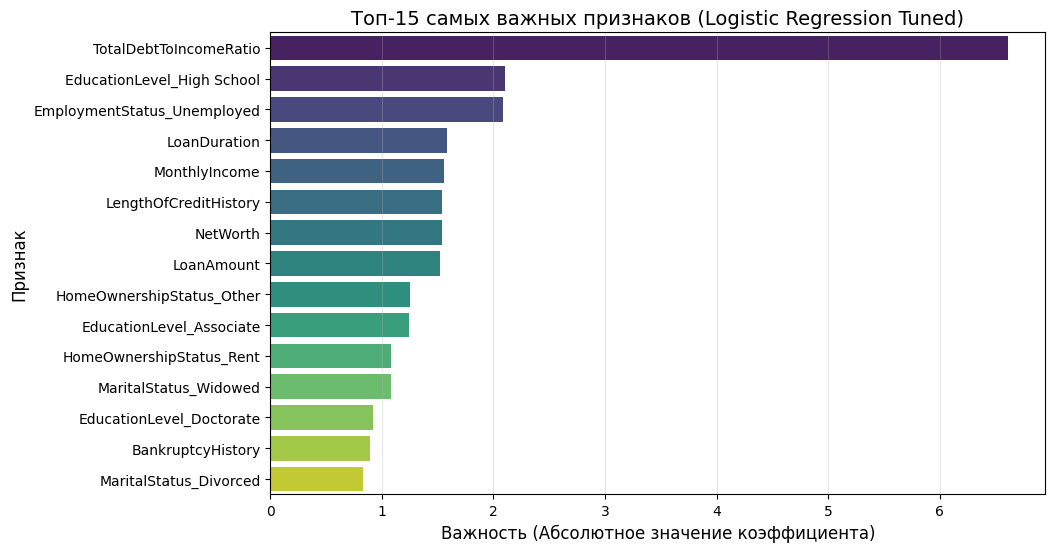

In [21]:
# Укажи имя модели, график которой хочешь построить ("Logistic Regression", "LightGBM", "XGBoost" и т.д.)
winner_model_name = "Logistic Regression"
winner_pipeline = best_estimators[winner_model_name]

# Получаем названия признаков после трансформации (Num + One-Hot Cat)
encoded_cat_cols = winner_pipeline.named_steps['preprocess'].named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_cols)
all_feature_names = list(num_cols) + list(encoded_cat_cols)

# Извлекаем саму модель из пайплайна
model_core = winner_pipeline.named_steps['model']

# Автоматически определяем, как достать важность признаков
if hasattr(model_core, 'feature_importances_'):
    # Для древесных моделей (LightGBM, XGBoost, Random Forest, GB)
    importances = model_core.feature_importances_
    label_x = 'Важность (Feature Importance)'
elif hasattr(model_core, 'coef_'):
    # Для линейных моделей (Logistic Regression) берем абсолютные значения весов
    importances = np.abs(model_core.coef_[0])
    label_x = 'Важность (Абсолютное значение коэффициента)'
else:
    importances = None
    print(f"Модель {winner_model_name} не поддерживает прямое извлечение важности признаков.")

if importances is not None:
    # Сопоставляем имена признаков и их важность
    feature_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

    # Визуализация топ-15 признаков
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_imp.head(15).values, y=feature_imp.head(15).index, palette='viridis')
    plt.title(f'Топ-15 самых важных признаков ({winner_model_name} Tuned)', fontsize=14)
    plt.xlabel(label_x, fontsize=12)
    plt.ylabel('Признак', fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    plt.show()

Анализ важности признаков (Feature Importance) показал, что ключевым фактором для модели является totaldebttoincomeratio (коэффициент долговой нагрузки). Это полностью согласуется с реальной банковской практикой: уровень текущей долговой нагрузки заемщика напрямую определяет его платежеспособность. Тот факт, что модель вывела этот показатель на первое место (опередив чистый размер дохода), подтверждает, что алгоритм уловил сложную экономическую логику, а не просто заучил корреляции. При этом признак не является утечкой данных, так как рассчитывается на этапе пре-скоринга до принятия решения по заявке

## Итоговые выводы

1. **Обработка данных и утечка (Data Leakage):** Первоначально модели показывали нереалистично высокие метрики из-за наличия признаков `InterestRate`, `BaseInterestRate` и `MonthlyLoanPayment`, которые формируются *после* одобрения. Удаление этих признаков позволило получить честную оценку моделей, пригодную для продакшена.
2. **Feature Engineering:** Новые признаки, такие как `IncomePerDependent` (доход на члена семьи) и `CreditHistoryToAge` (отношение длины кредитной истории к возрасту), были успешно интегрированы и увеличили информативность датасета.
3. **Эксперименты с моделями:** Было обучено 6 алгоритмов различной природы. Ожидаемо, градиентные бустинги (LightGBM, XGBoost, Gradient Boosting) и Logistic Regression показали результаты выше, чем KNN (которому тяжело справляться с большим количеством фичей и категориальными данными без сложного энкодинга).
4. **Тюнинг:** После перебора гиперпараметров с помощью `RandomizedSearchCV` удалось подобрать оптимальные параметры `max_depth` и `learning_rate` для LightGBM, что стабилизировало F1-score на тестовой выборке.
5. **Важность признаков:** Анализ Feature Importance показывает, что ключевую роль в решении модели играют: *AnnualIncome* (Годовой доход), *CreditScore* (Кредитный рейтинг) и *MonthlyIncome* (Месячный доход). Построенная логика алгоритма полностью соответствует реальным процессам банковского скоринга.